In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_spike_to_avg_distances,
    plot_spike_feature_within_vs_between,
)
import config
from config import SPE1_PICKLE_ROOT

In [2]:
cluster_pickle_dir = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles')
spike_fit_dir      = os.path.join(SPE1_PICKLE_ROOT, 'spike_fit_pickles')

In [3]:
df_master = compile_experiment_results(cluster_pickle_dir)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)
df_master = df_master.sort_values(['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])

## Spike-to-average vs between-cell waveform distances

Within = each individual spike vs its own cell's mean waveform (~167k spikes). Between = each spike vs every other cell's mean (~7M comparisons). Both are spike-to-average nRMSE/cos_sim.

[spike_to_avg] cache HIT — loading


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2660: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2663: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


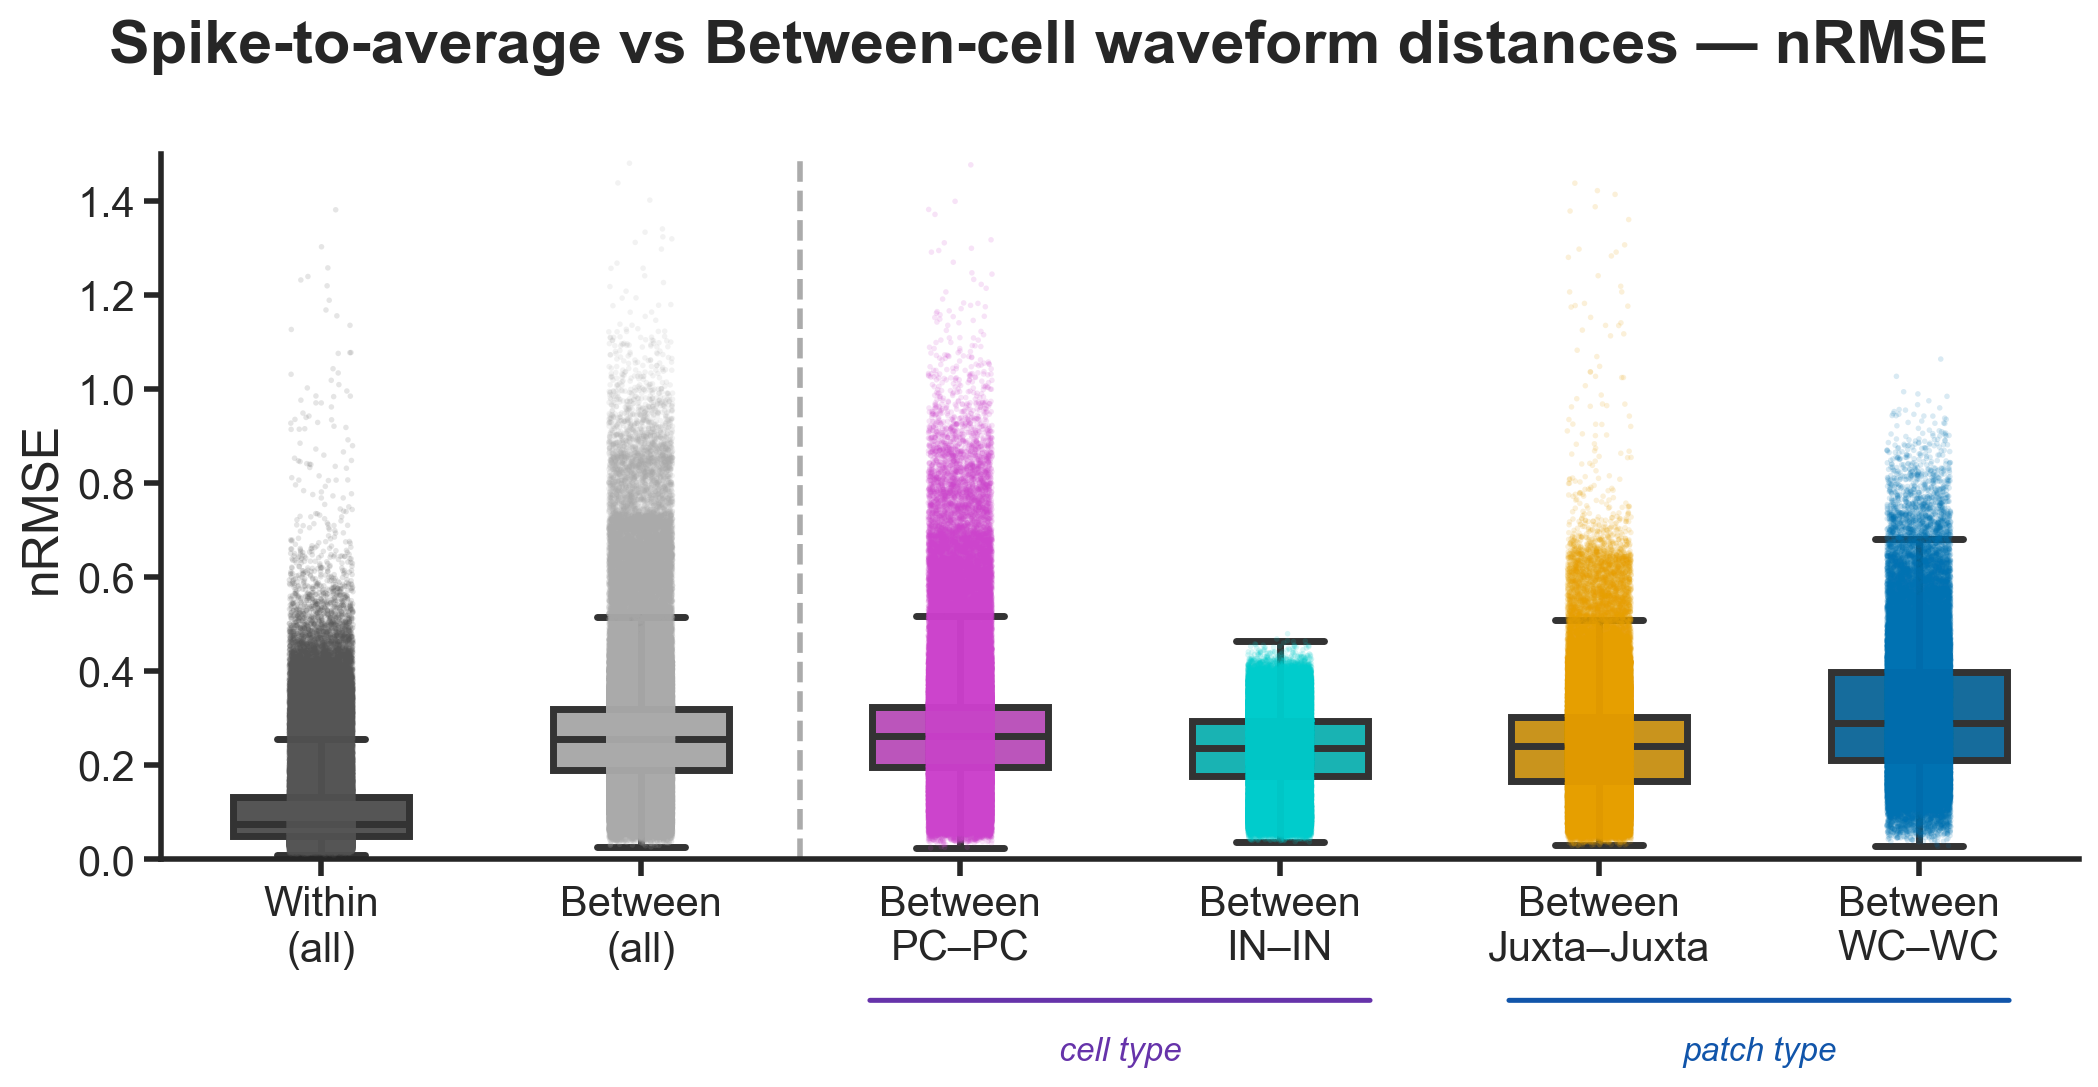


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.189, 0.320]  n=200000
  Between PC–PC         : median=0.263  IQR=[0.196, 0.325]  n=200000
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=200000
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=200000
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2660: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2663: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=GROUP_ORDER,


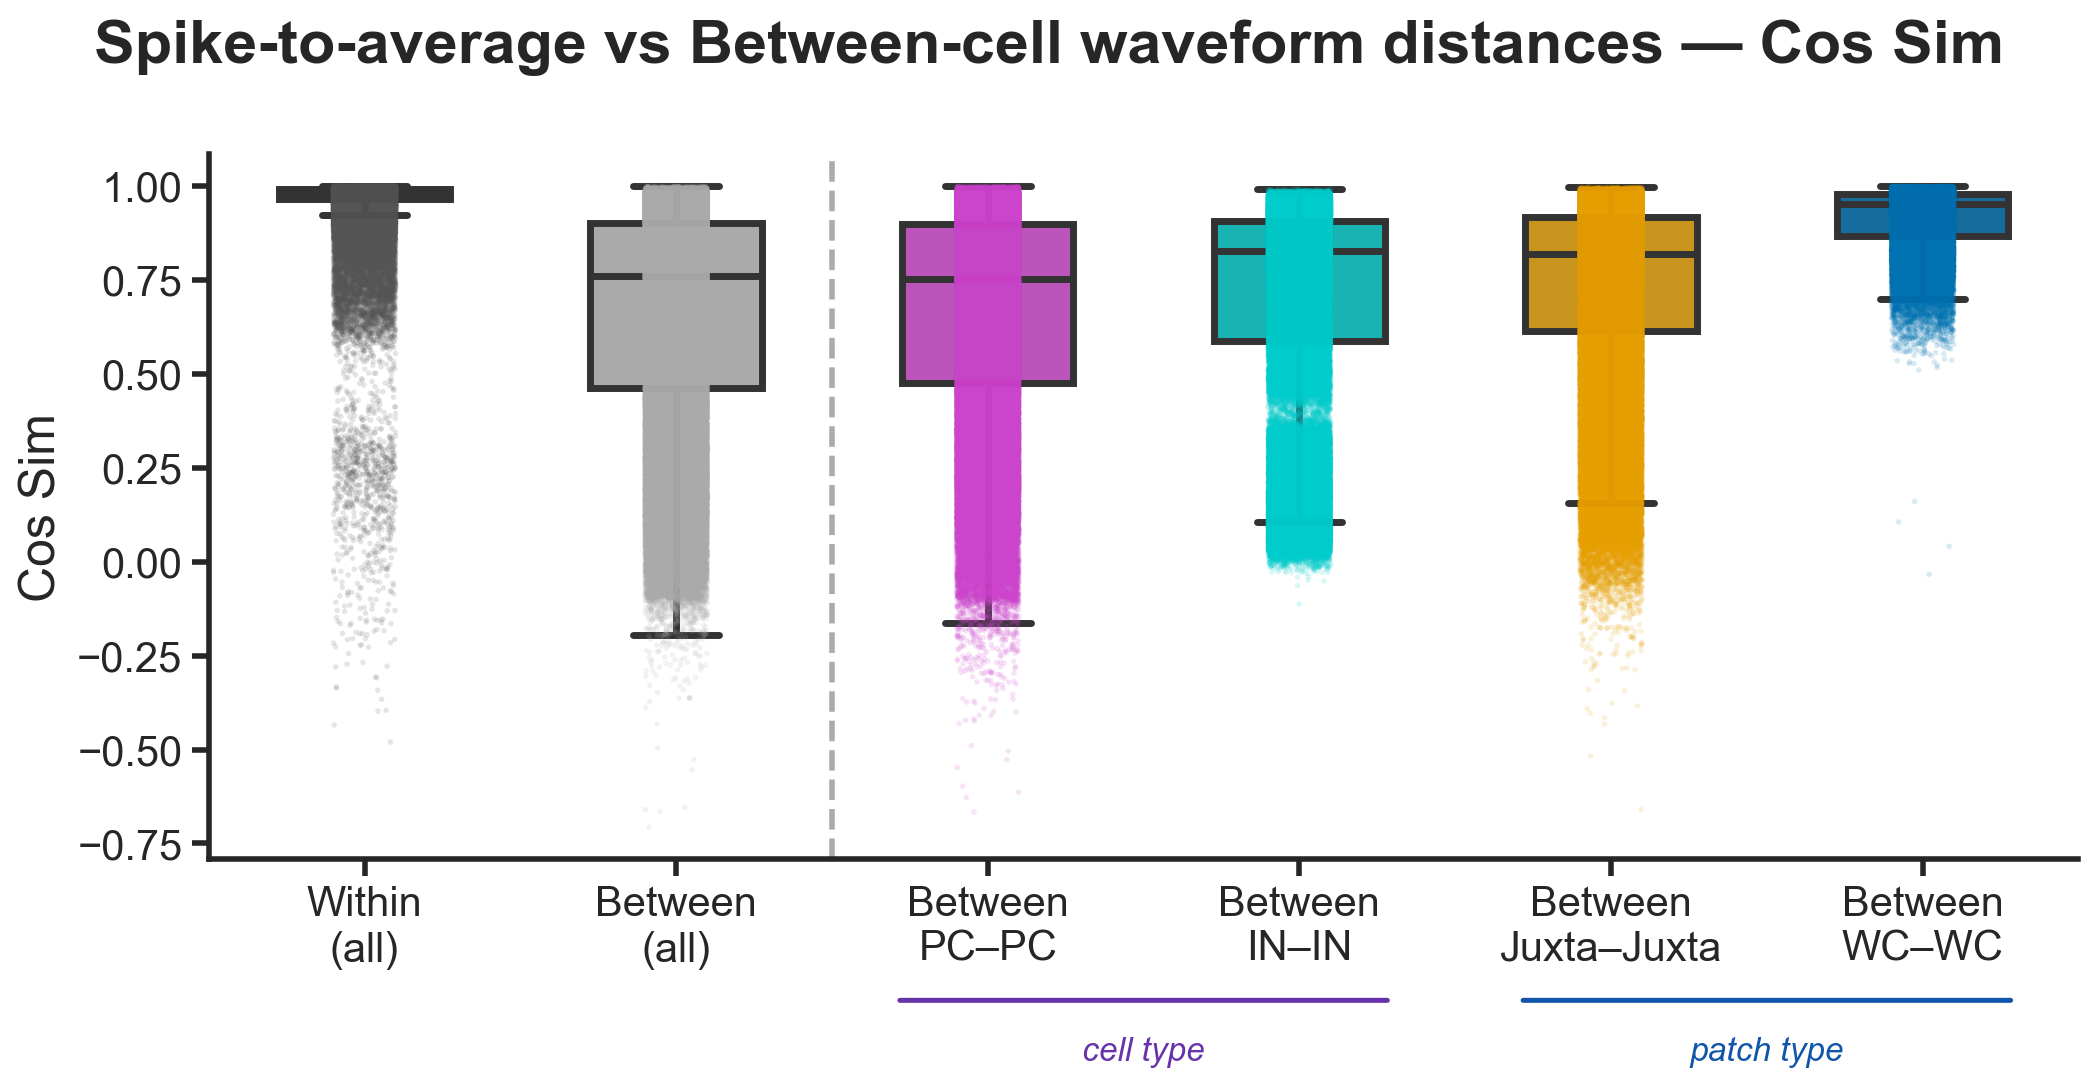


── Cos Sim (spike-to-avg) ──
  Within (all)          : median=0.984  IQR=[0.965, 0.992]  n=167006
  Between (all)         : median=0.761  IQR=[0.464, 0.903]  n=200000
  Between PC–PC         : median=0.753  IQR=[0.475, 0.900]  n=200000
  Between IN–IN         : median=0.828  IQR=[0.587, 0.908]  n=200000
  Between Juxta–Juxta   : median=0.818  IQR=[0.614, 0.918]  n=200000
  Between WC–WC         : median=0.953  IQR=[0.868, 0.979]  n=77752


In [4]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=cluster_pickle_dir,
    spike_fit_dir=spike_fit_dir,
    half_win=75,
)

## Within vs between: waveform nRMSE per spike feature

For each waveform feature (cells with clustering for that feature only): within = waveform nRMSE of each spike vs its own cell's mean waveform; between = waveform nRMSE of each spike vs every other cell's mean waveform.

[spike_feature_wb] mode=simple  cache=MISS — computing (will cache after)
Loaded waveforms for 43 cells
  peak_amp             Within                : nRMSE median=0.1561  RMSE median=3.666  n=48,108
  peak_amp             Between               : nRMSE median=0.302  RMSE median=26.07  n=625,404
  peak_amp: cached → _feat_wbwf2_simple_peak_amp.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


  peak_sharpness       Within                : nRMSE median=0.1068  RMSE median=4.512  n=68,634
  peak_sharpness       Between               : nRMSE median=0.3204  RMSE median=61.12  n=754,974
  peak_sharpness: cached → _feat_wbwf2_simple_peak_sharpness.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


  peak_width           Within                : nRMSE median=0.092  RMSE median=10.73  n=82,725
  peak_width           Between               : nRMSE median=0.2586  RMSE median=52.67  n=1,158,150
  peak_width: cached → _feat_wbwf2_simple_peak_width.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


  exp_lambda           Within                : nRMSE median=0.07747  RMSE median=16.88  n=51,900
  exp_lambda           Between               : nRMSE median=0.1944  RMSE median=51.03  n=570,900
  exp_lambda: cached → _feat_wbwf2_simple_exp_lambda.npz
  inflection_amp       Within                : nRMSE median=0.3275  RMSE median=4.297  n=14,949
  inflection_amp       Between               : nRMSE median=0.3025  RMSE median=5.972  n=14,949
  inflection_amp: cached → _feat_wbwf2_simple_inflection_amp.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passi

  inflection_time      Within                : nRMSE median=0.06766  RMSE median=3.792  n=34,780
  inflection_time      Between               : nRMSE median=0.3255  RMSE median=68.11  n=104,340
  inflection_time: cached → _feat_wbwf2_simple_inflection_time.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


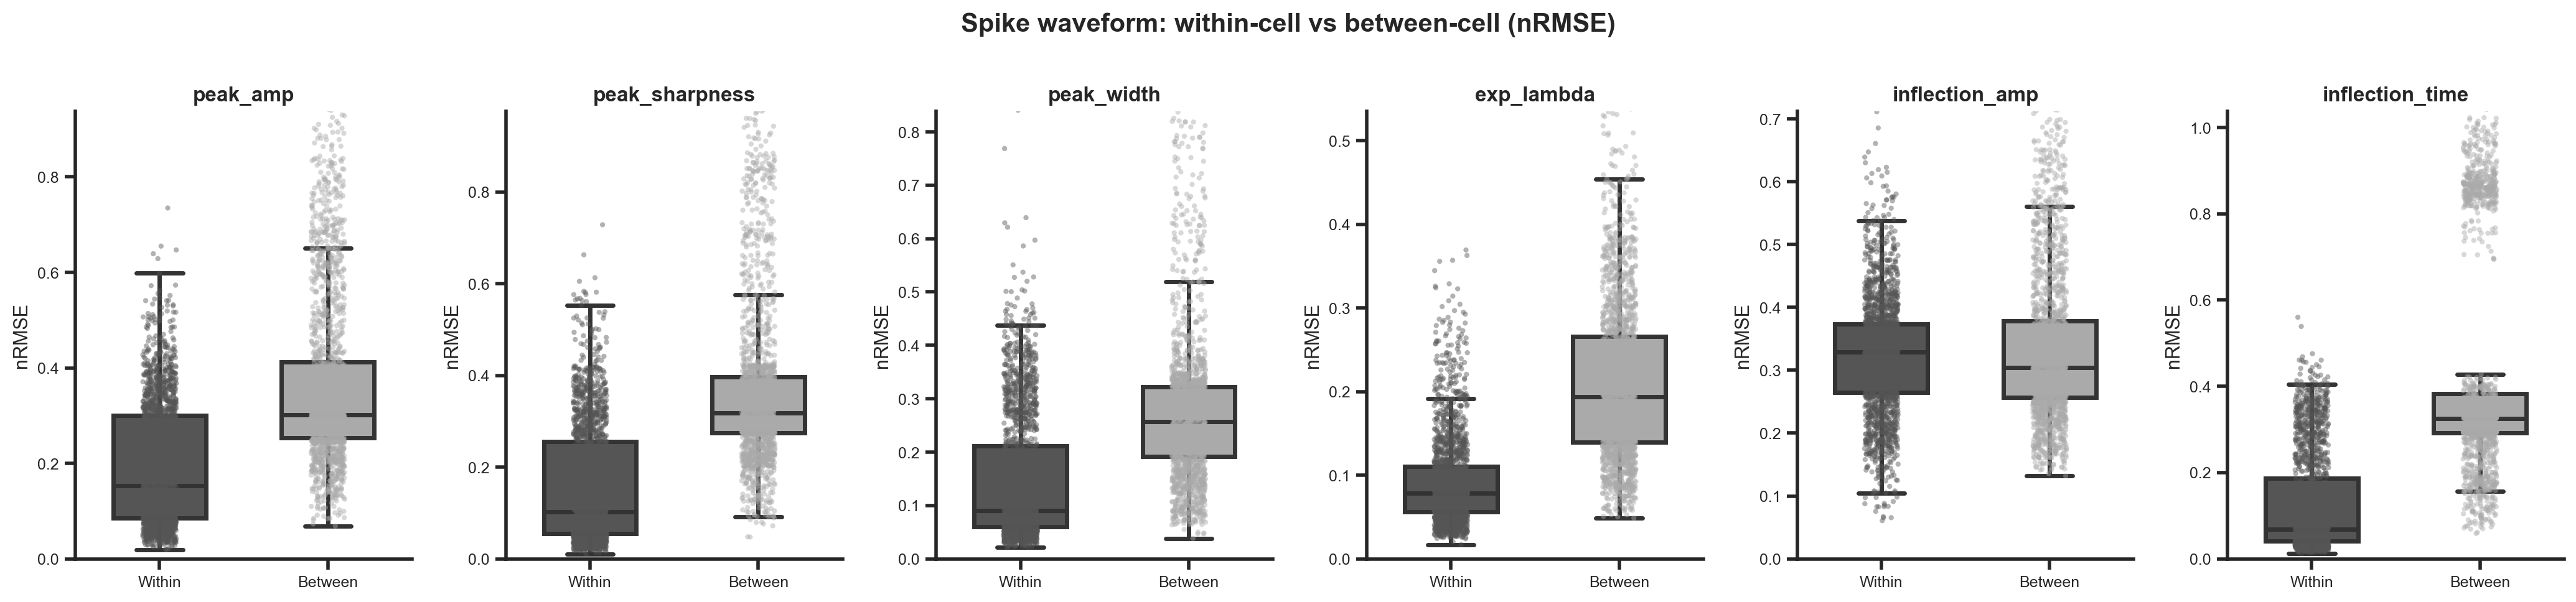

  peak_amp: loaded from cache
  peak_sharpness: loaded from cache
  peak_width: loaded from cache


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passi

  exp_lambda: loaded from cache
  inflection_amp: loaded from cache
  inflection_time: loaded from cache


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passi

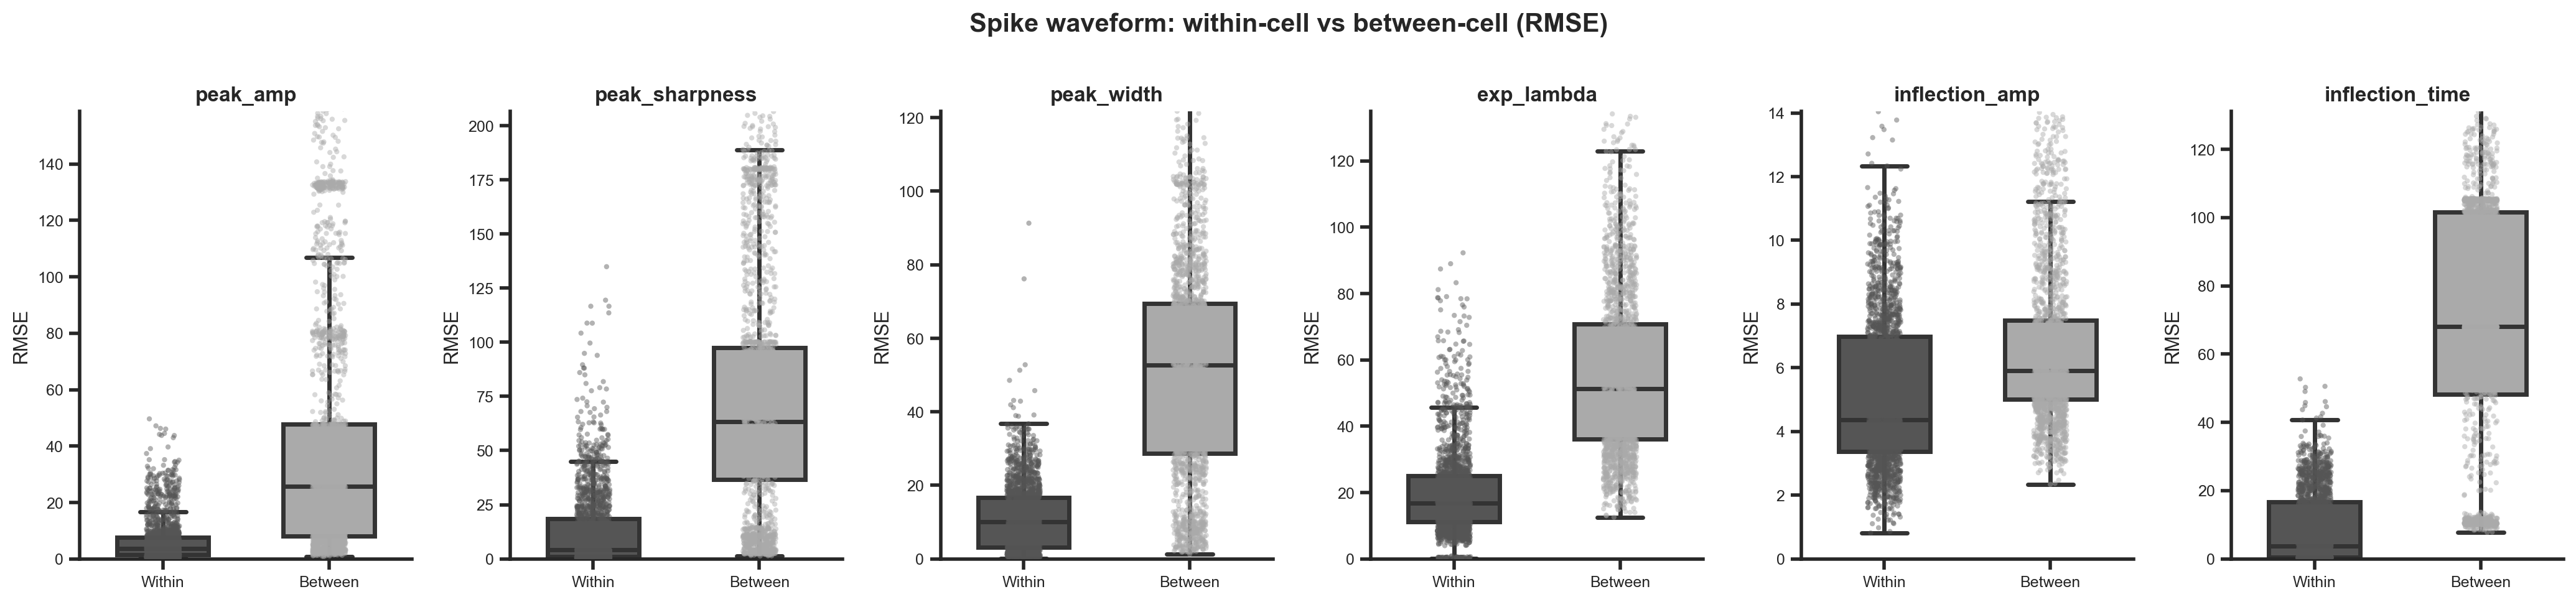

In [5]:
plot_spike_feature_within_vs_between(cluster_pickle_dir, spike_fit_dir)

[spike_feature_wb] mode=detailed  cache=MISS — computing (will cache after)
Loaded waveforms for 43 cells
  peak_amp             Within (all)          : nRMSE median=0.1561  RMSE median=3.666  n=48,108
  peak_amp             Between (all)         : nRMSE median=0.302  RMSE median=26.07  n=625,404
  peak_amp             Between PC–PC         : nRMSE median=0.302  RMSE median=26.07  n=625,404
  peak_amp             Between Juxta–Juxta   : nRMSE median=0.2757  RMSE median=40.19  n=277,776
  peak_amp             Between WC–WC         : nRMSE median=0.3001  RMSE median=5.768  n=51,732
  peak_amp: cached → _feat_wbwf2_detailed_peak_amp.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


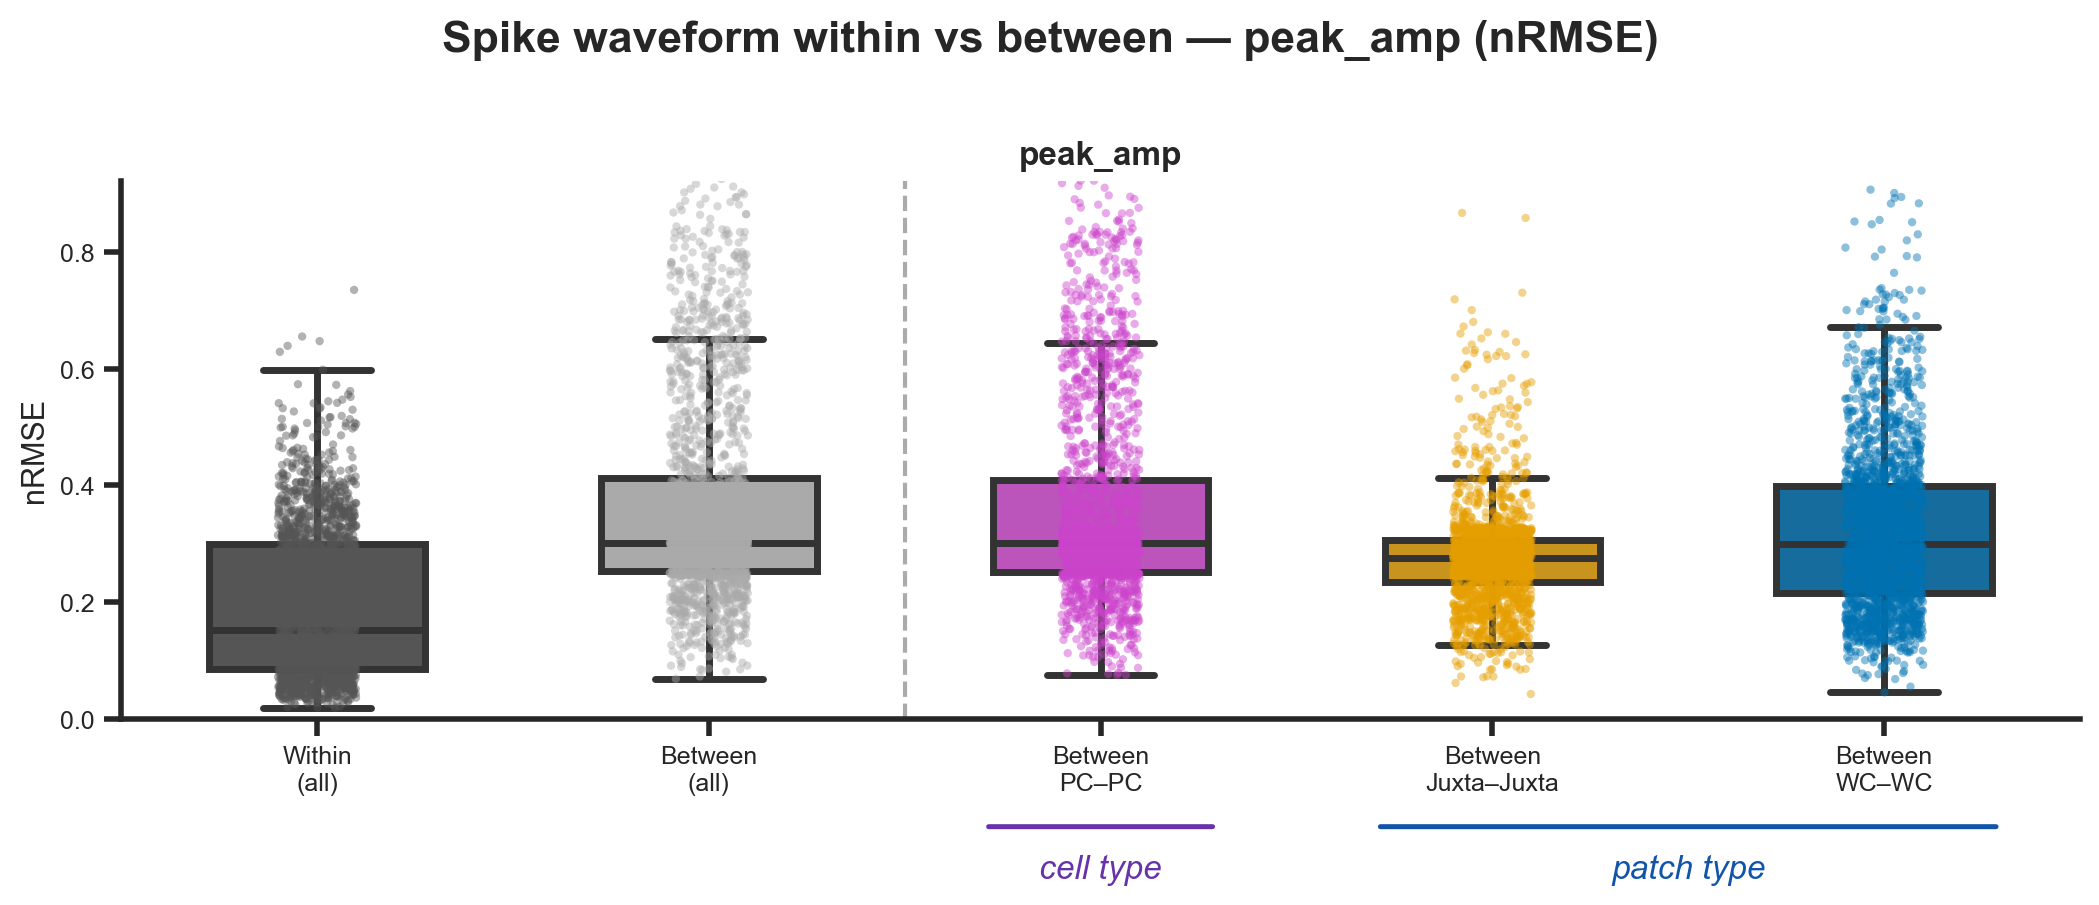

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


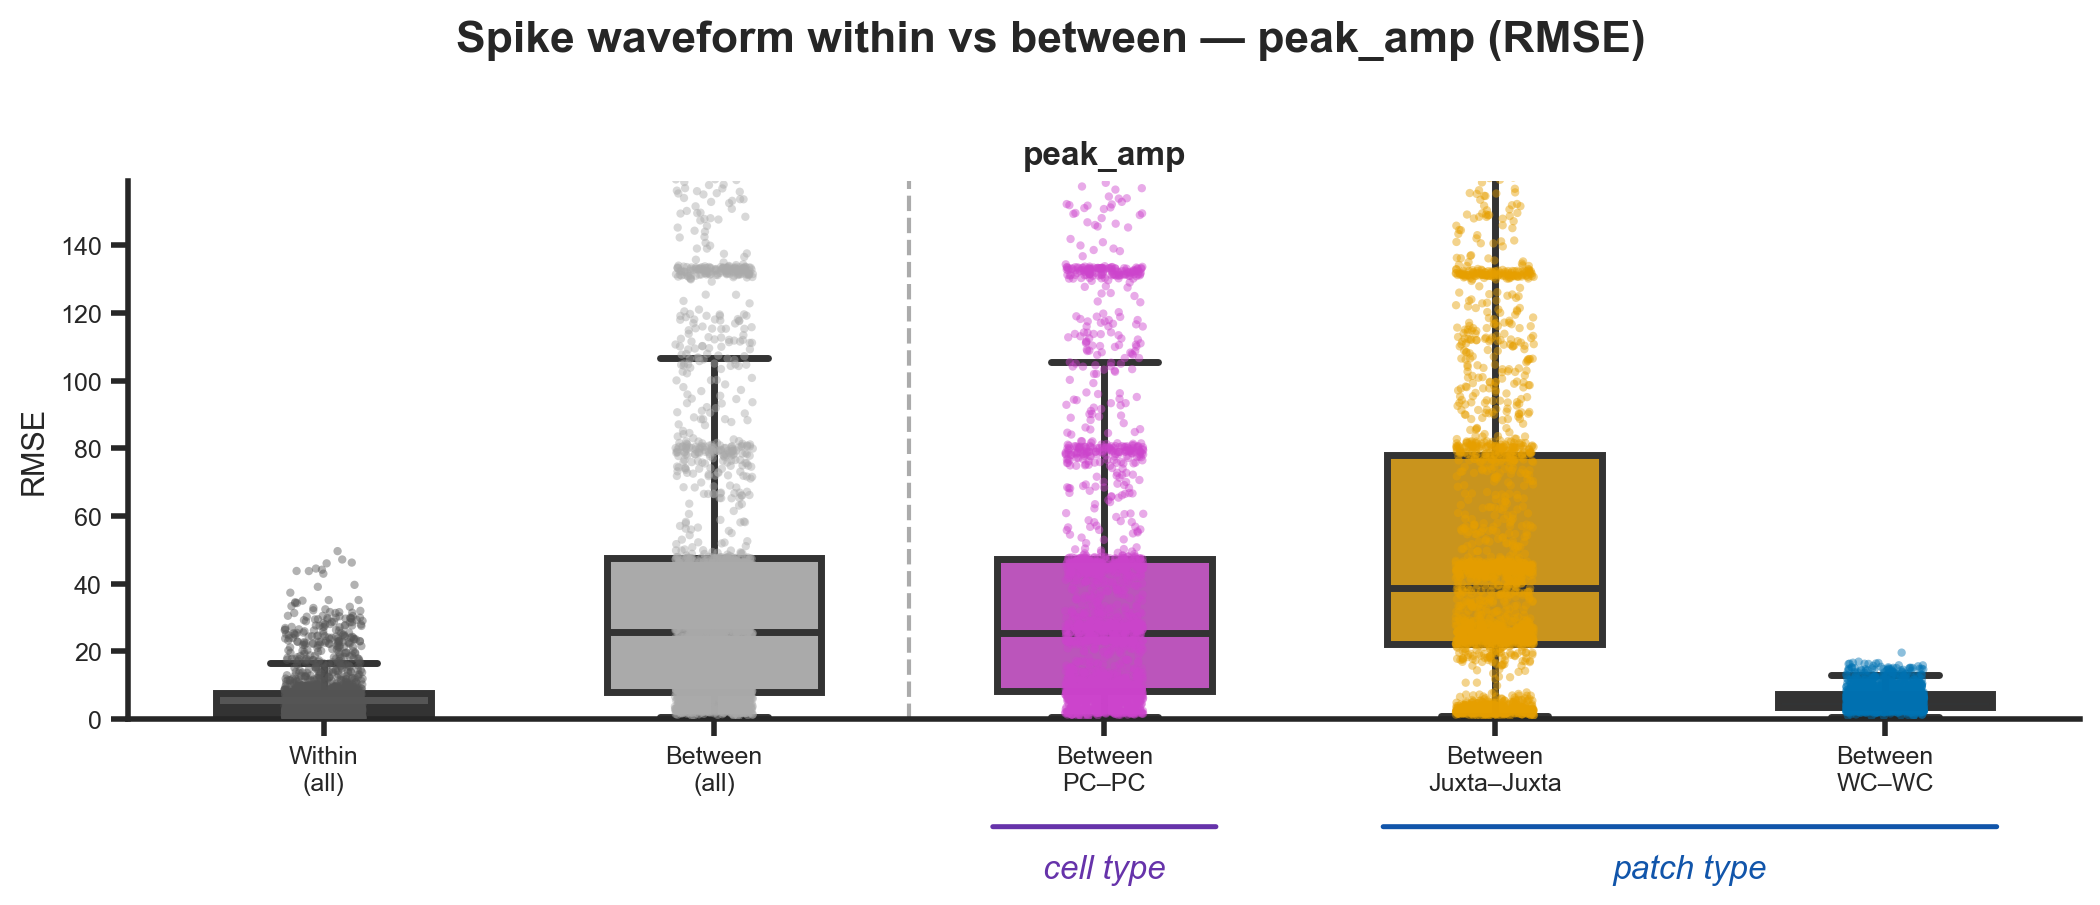

  peak_sharpness       Within (all)          : nRMSE median=0.1068  RMSE median=4.512  n=68,634
  peak_sharpness       Between (all)         : nRMSE median=0.3204  RMSE median=61.12  n=754,974
  peak_sharpness       Between PC–PC         : nRMSE median=0.3292  RMSE median=65.56  n=448,164
  peak_sharpness       Between IN–IN         : nRMSE median=0.2946  RMSE median=68.17  n=18,838
  peak_sharpness       Between Juxta–Juxta   : nRMSE median=0.295  RMSE median=68.23  n=483,165
  peak_sharpness       Between WC–WC         : nRMSE median=0.3025  RMSE median=5.972  n=14,949
  peak_sharpness: cached → _feat_wbwf2_detailed_peak_sharpness.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


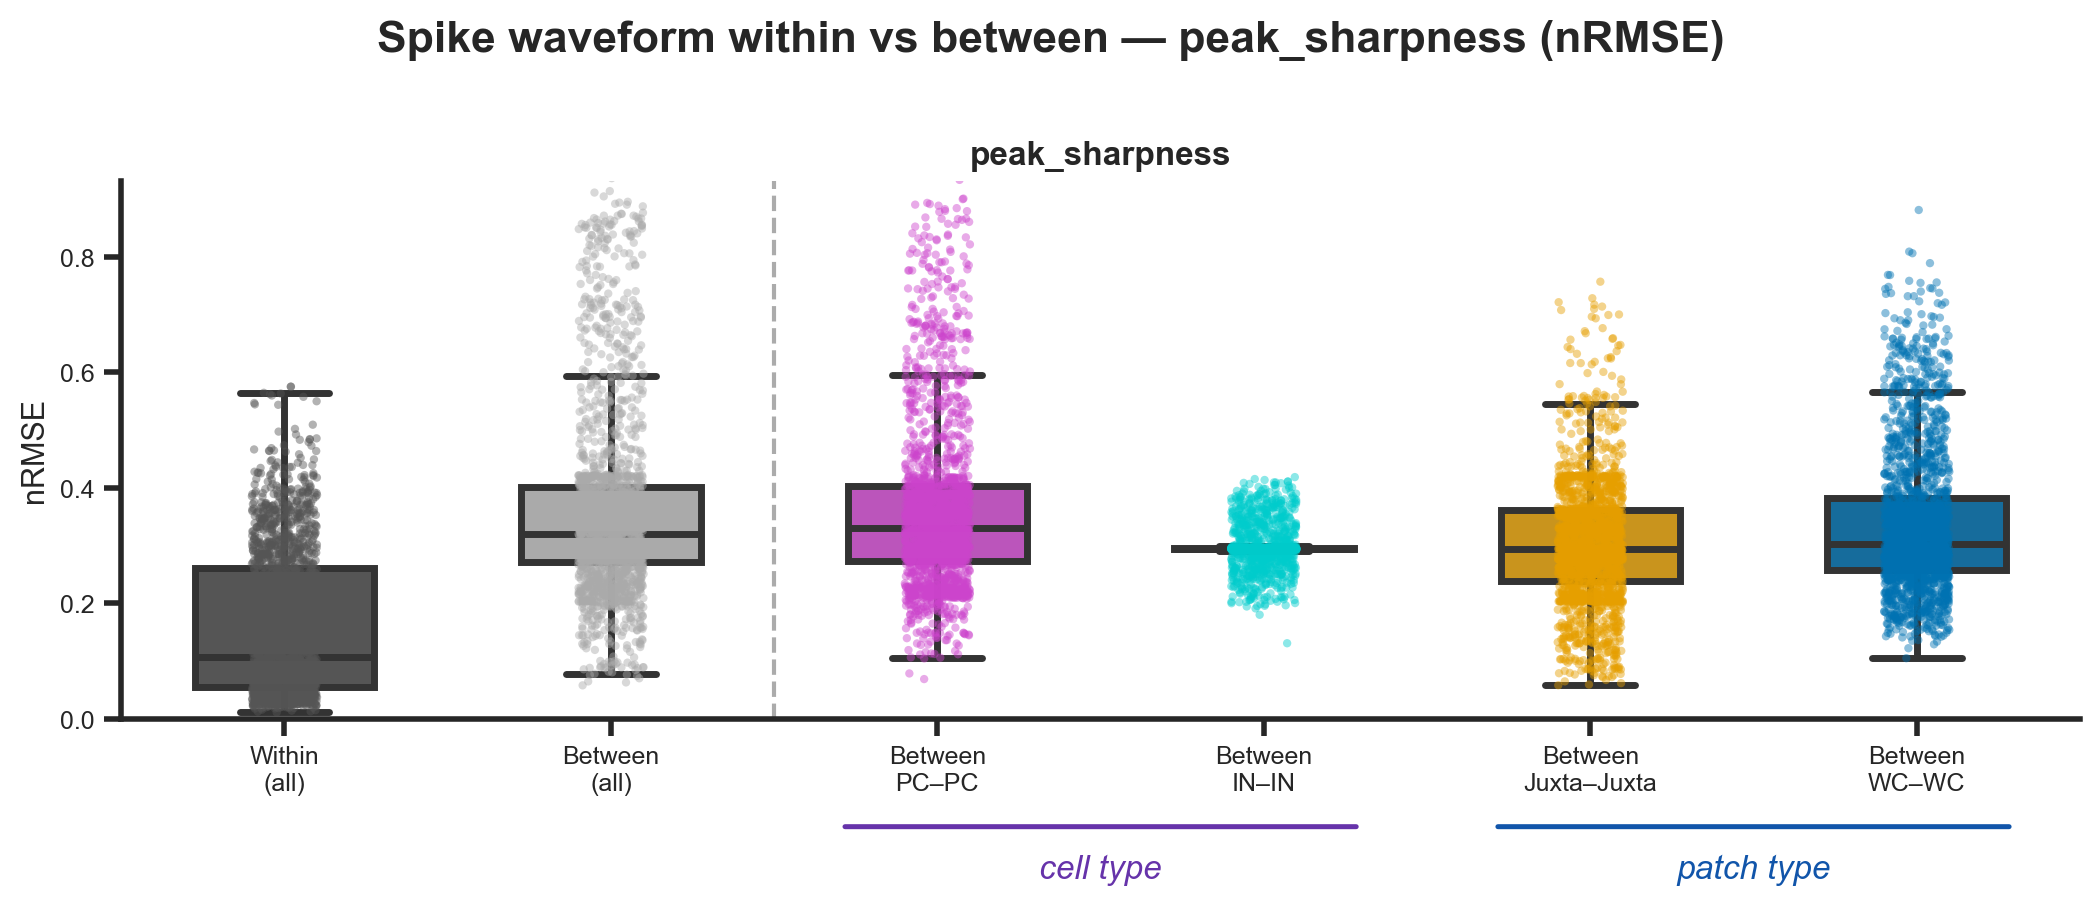

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


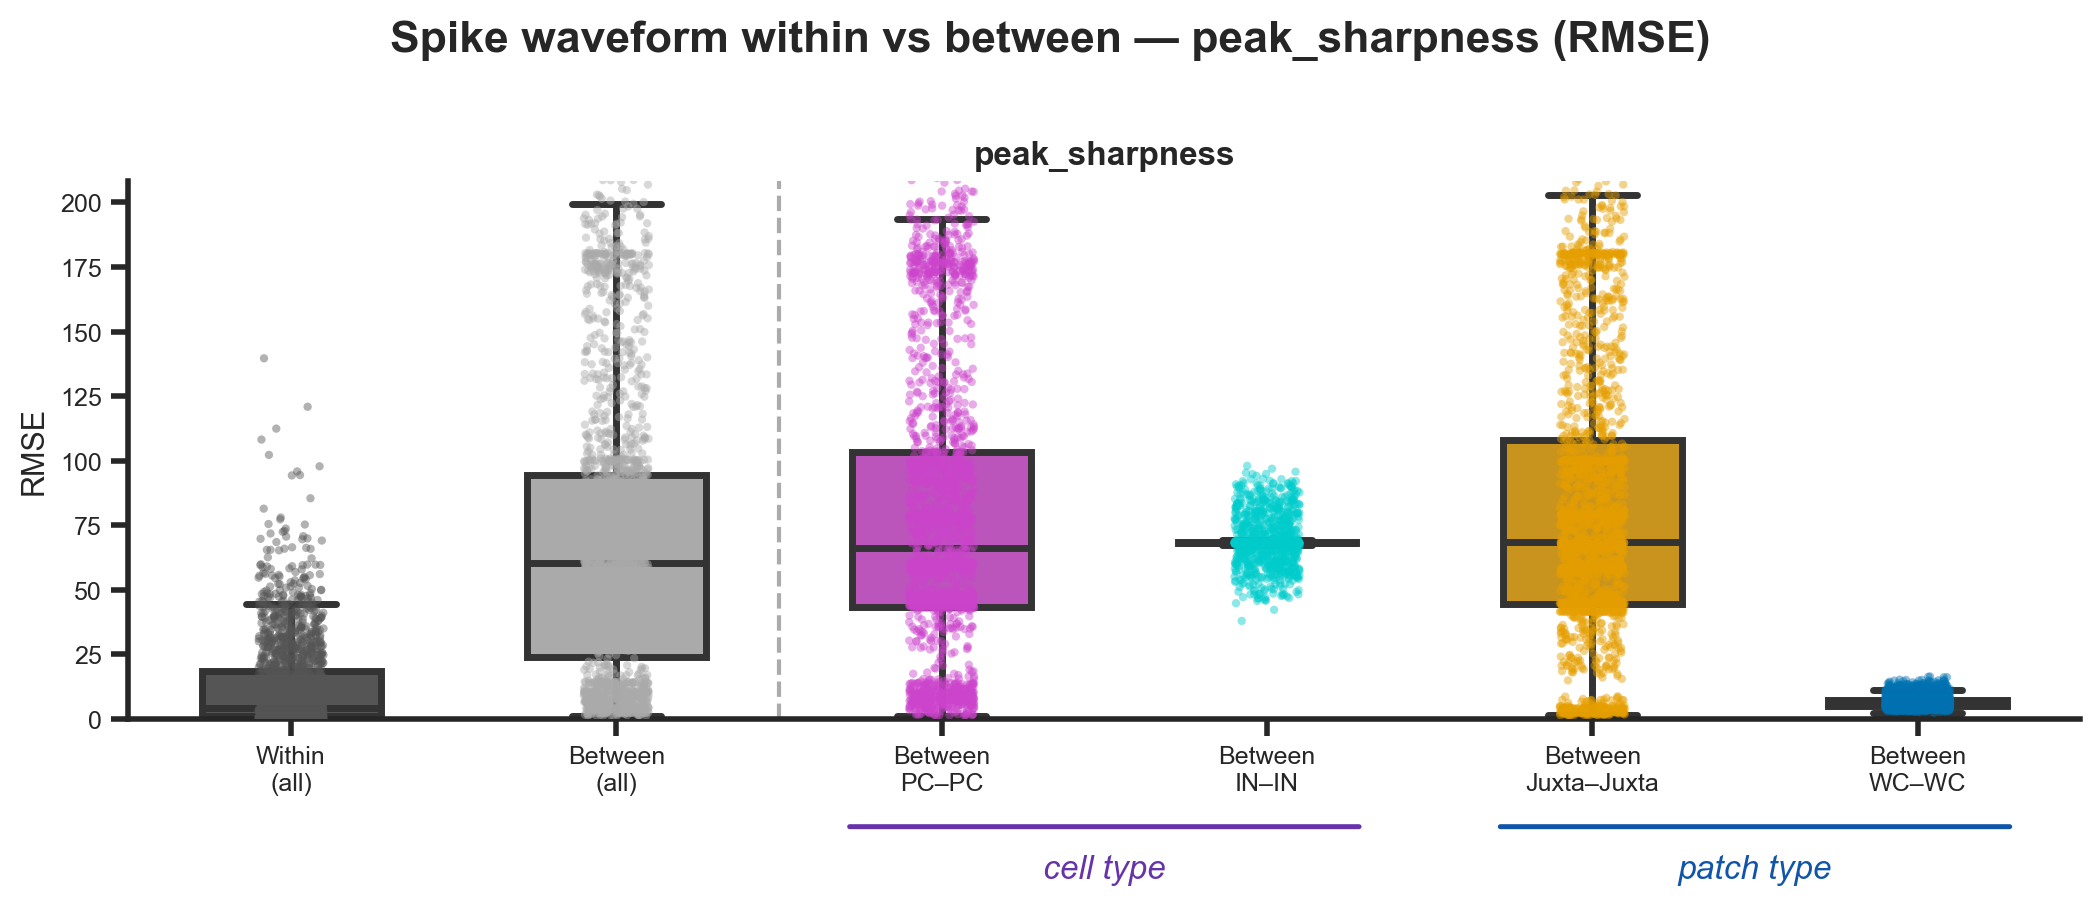

  peak_width           Within (all)          : nRMSE median=0.092  RMSE median=10.73  n=82,725
  peak_width           Between (all)         : nRMSE median=0.2586  RMSE median=52.67  n=1,158,150
  peak_width           Between PC–PC         : nRMSE median=0.2823  RMSE median=51.51  n=699,875
  peak_width           Between IN–IN         : nRMSE median=0.2033  RMSE median=64.48  n=38,200
  peak_width           Between Juxta–Juxta   : nRMSE median=0.2196  RMSE median=53.09  n=736,428
  peak_width           Between WC–WC         : nRMSE median=0.3047  RMSE median=5.973  n=31,554
  peak_width: cached → _feat_wbwf2_detailed_peak_width.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


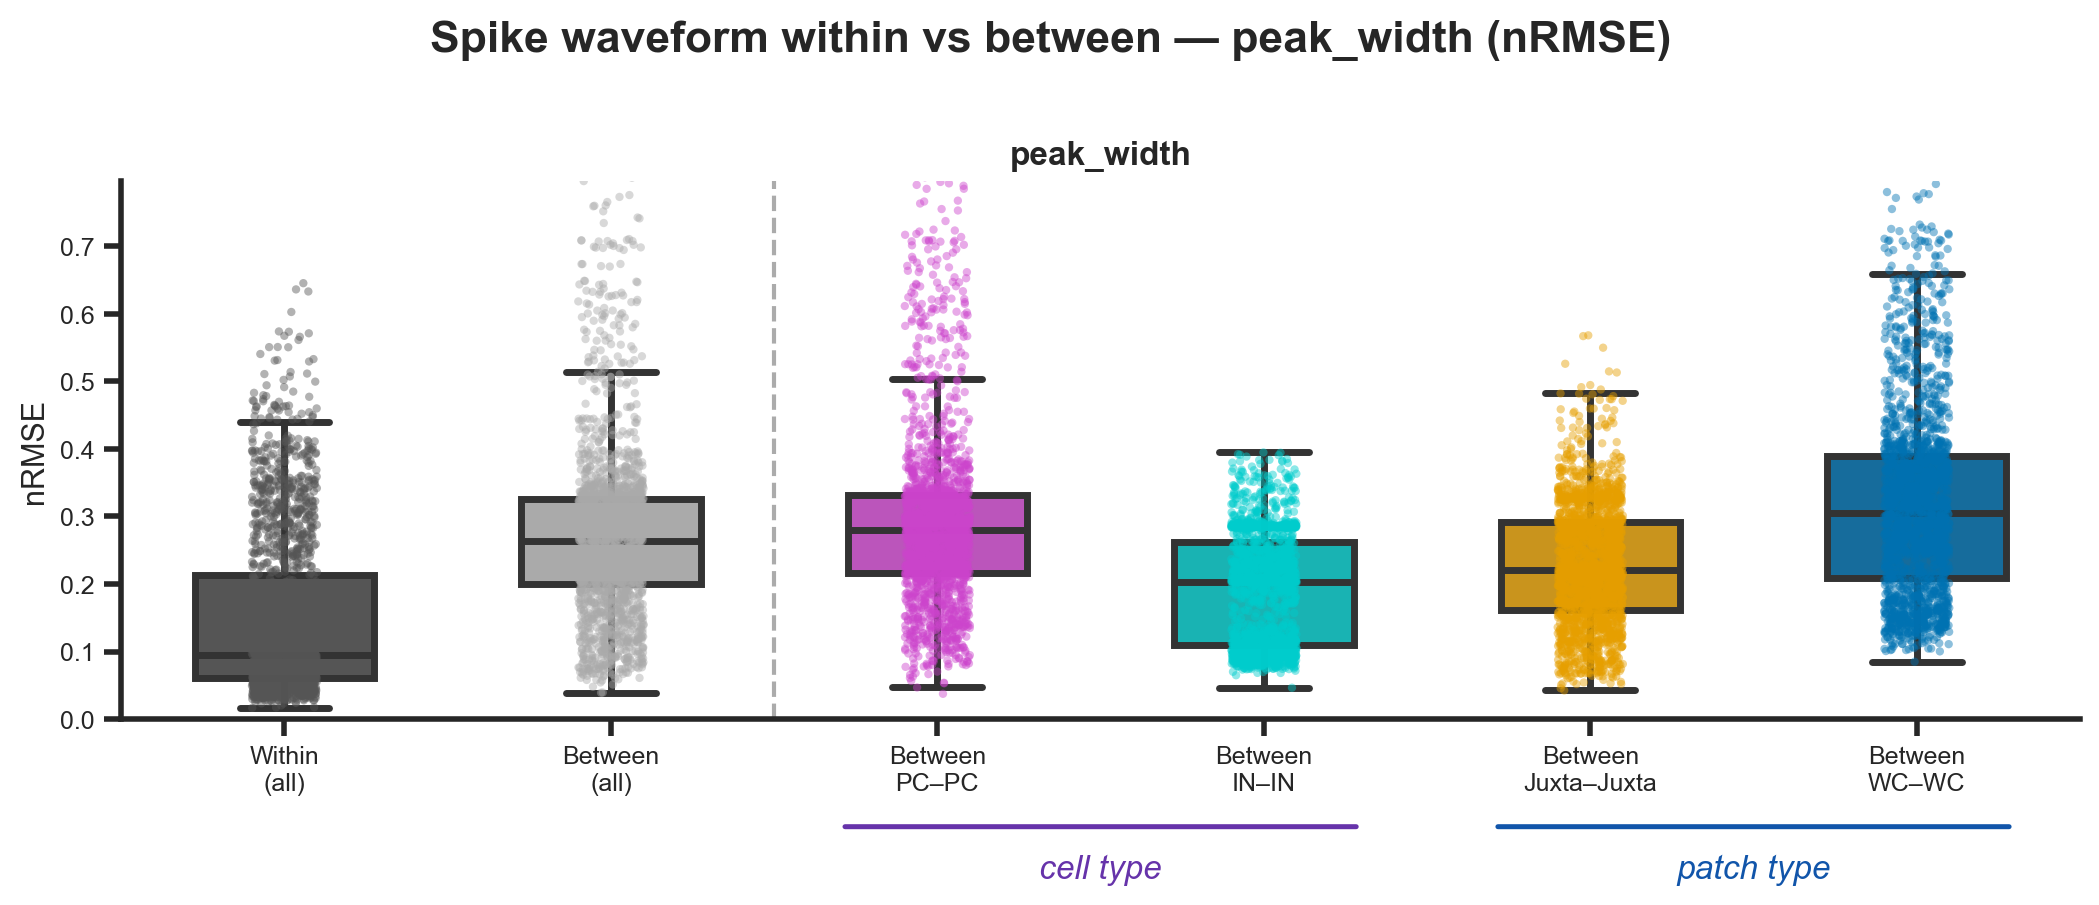

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


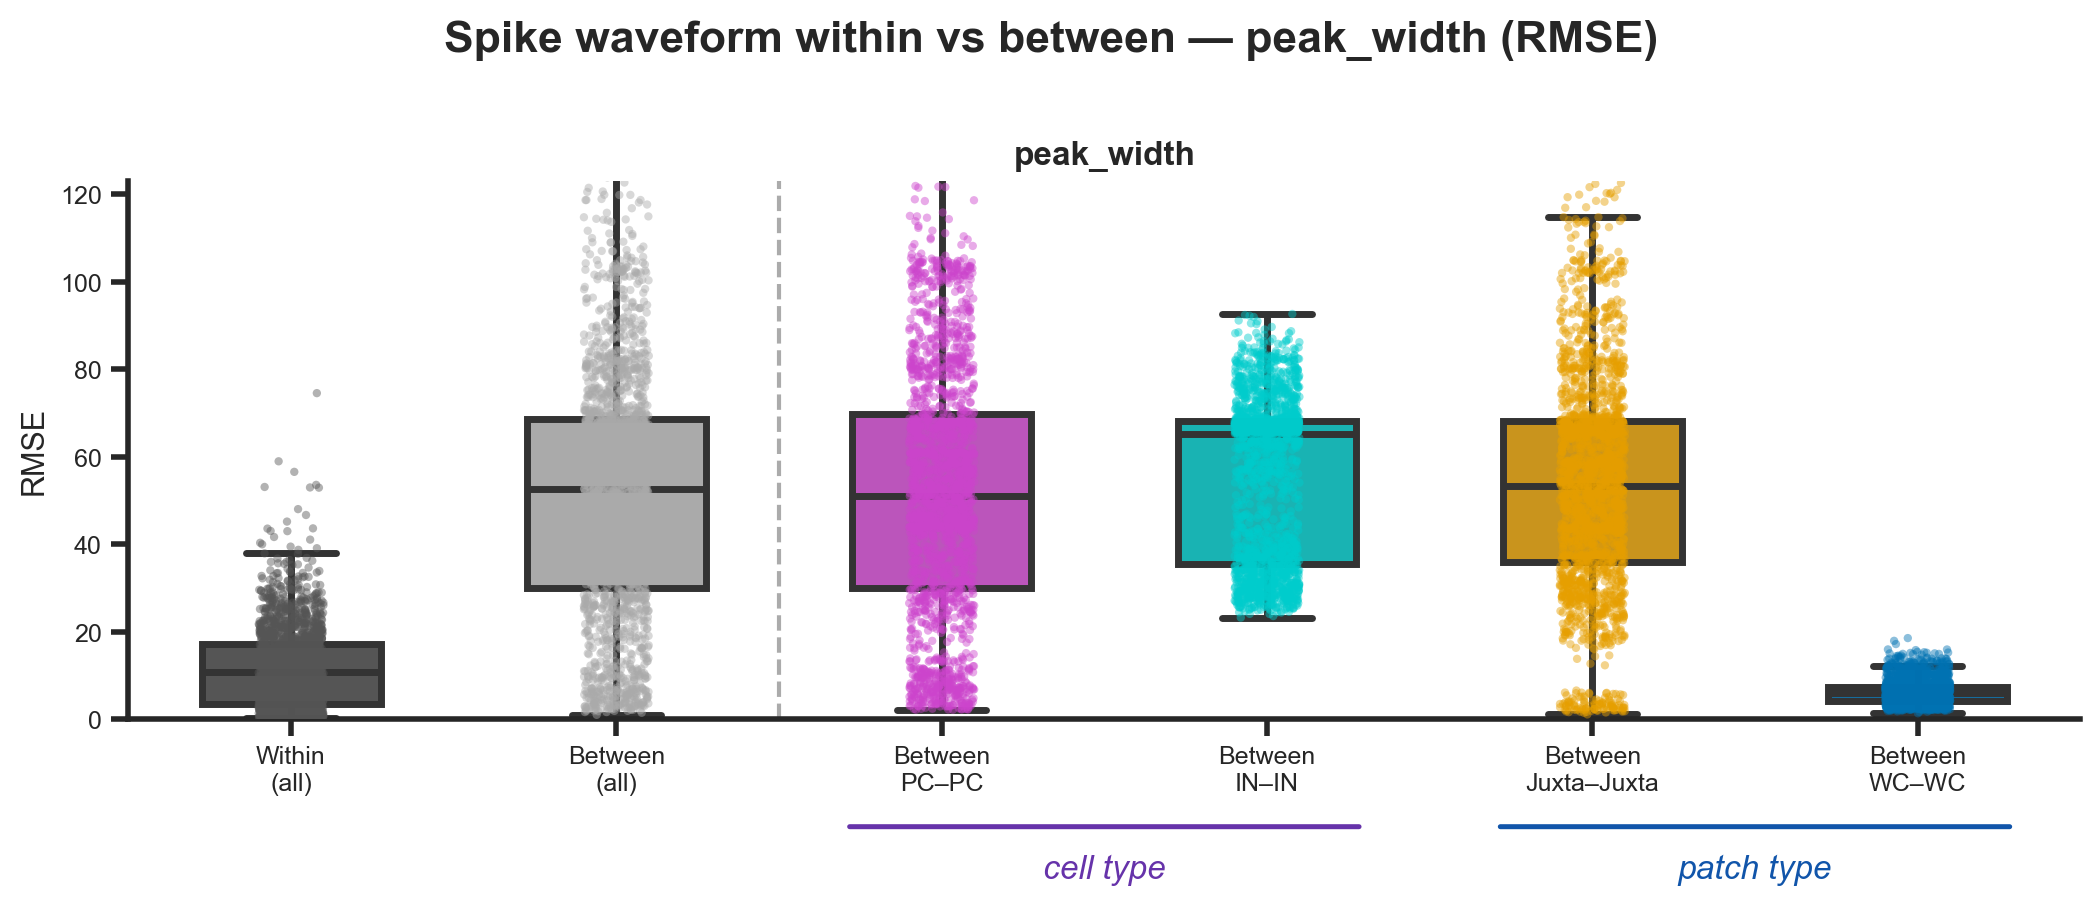

  exp_lambda           Within (all)          : nRMSE median=0.07747  RMSE median=16.88  n=51,900
  exp_lambda           Between (all)         : nRMSE median=0.1944  RMSE median=51.03  n=570,900
  exp_lambda           Between PC–PC         : nRMSE median=0.2097  RMSE median=54.81  n=450,590
  exp_lambda           Between Juxta–Juxta   : nRMSE median=0.1944  RMSE median=51.03  n=570,900
  exp_lambda: cached → _feat_wbwf2_detailed_exp_lambda.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


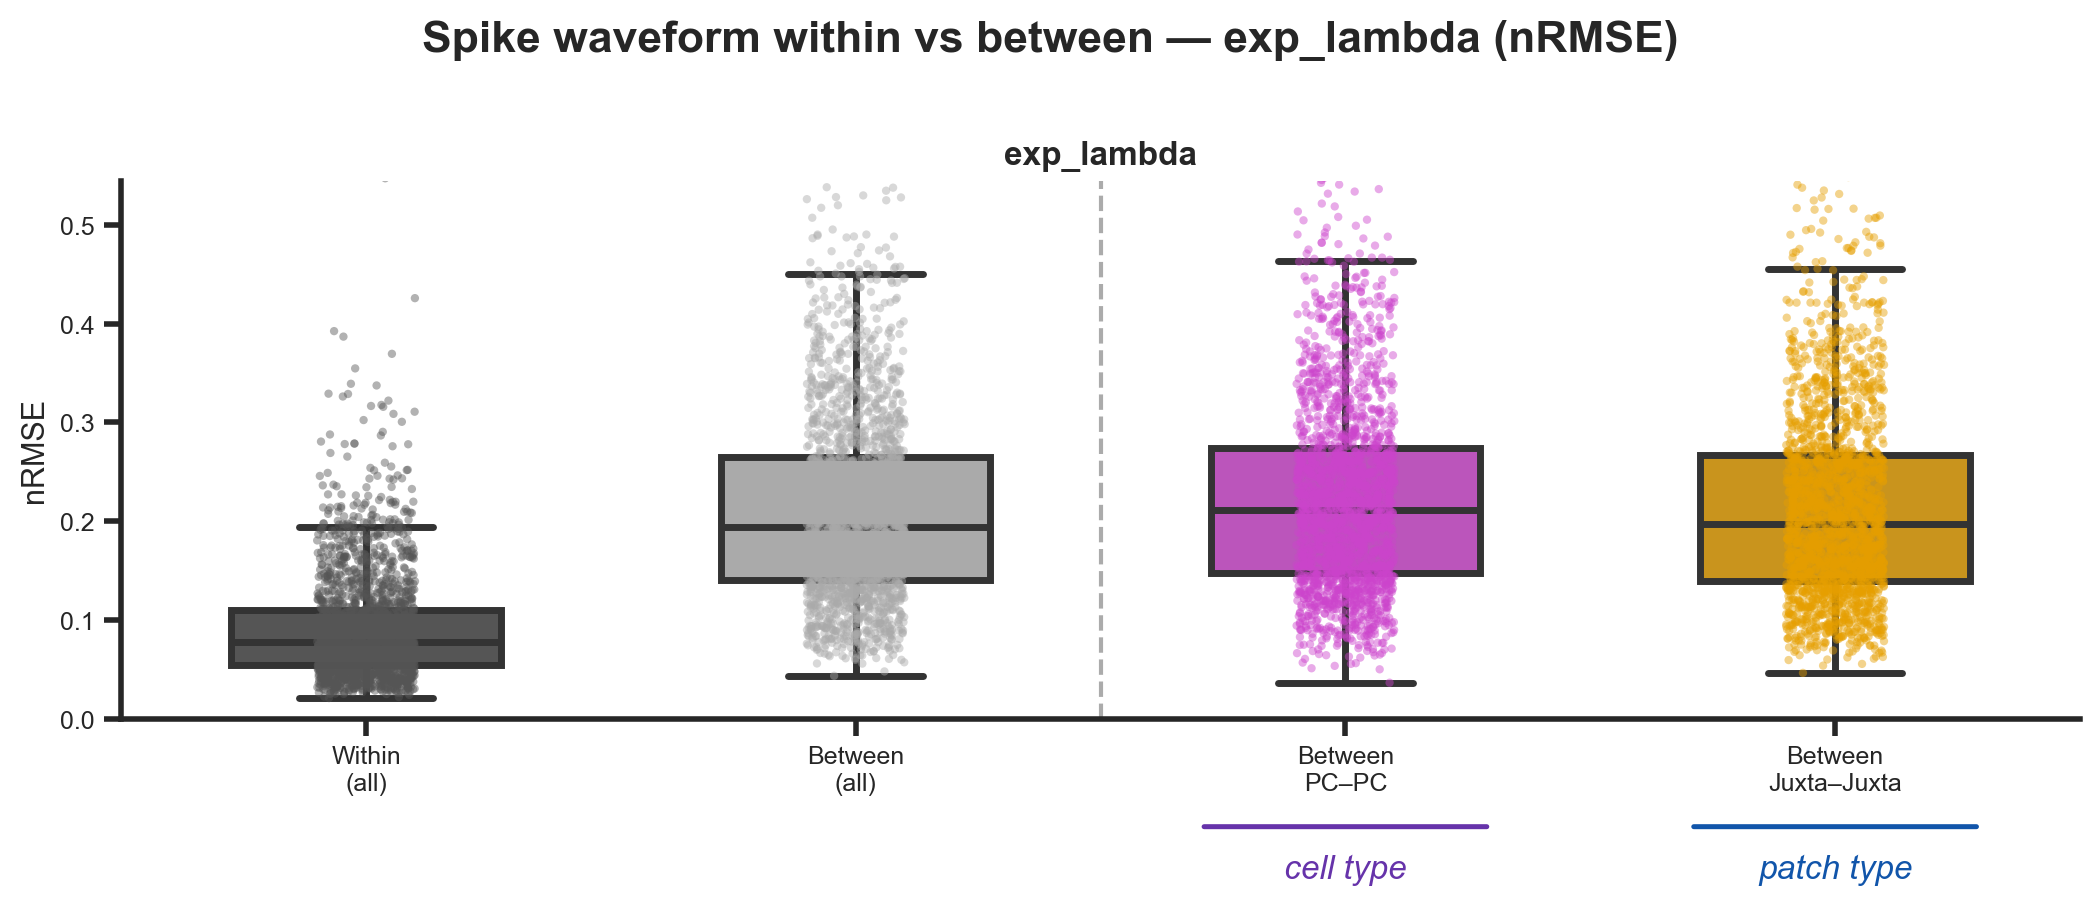

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


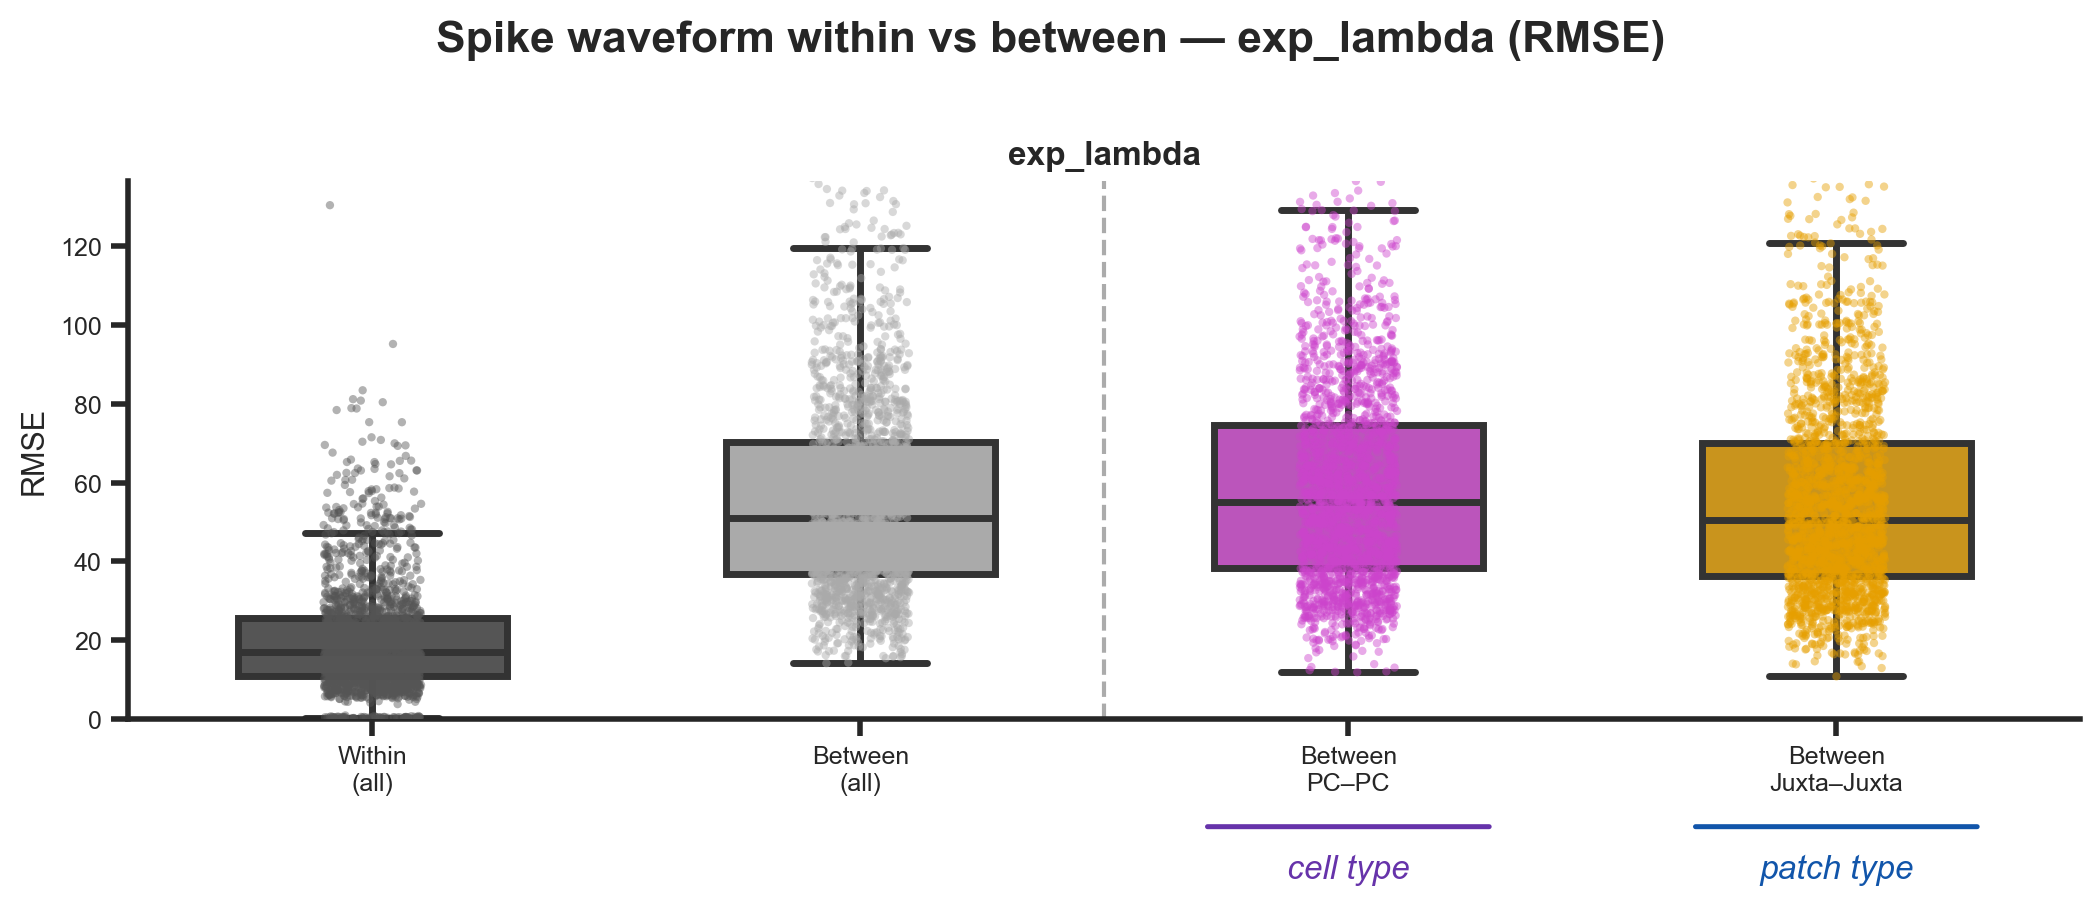

  inflection_amp       Within (all)          : nRMSE median=0.3275  RMSE median=4.297  n=14,949
  inflection_amp       Between (all)         : nRMSE median=0.3025  RMSE median=5.972  n=14,949
  inflection_amp       Between PC–PC         : nRMSE median=0.3025  RMSE median=5.972  n=14,949
  inflection_amp       Between WC–WC         : nRMSE median=0.3025  RMSE median=5.972  n=14,949
  inflection_amp: cached → _feat_wbwf2_detailed_inflection_amp.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


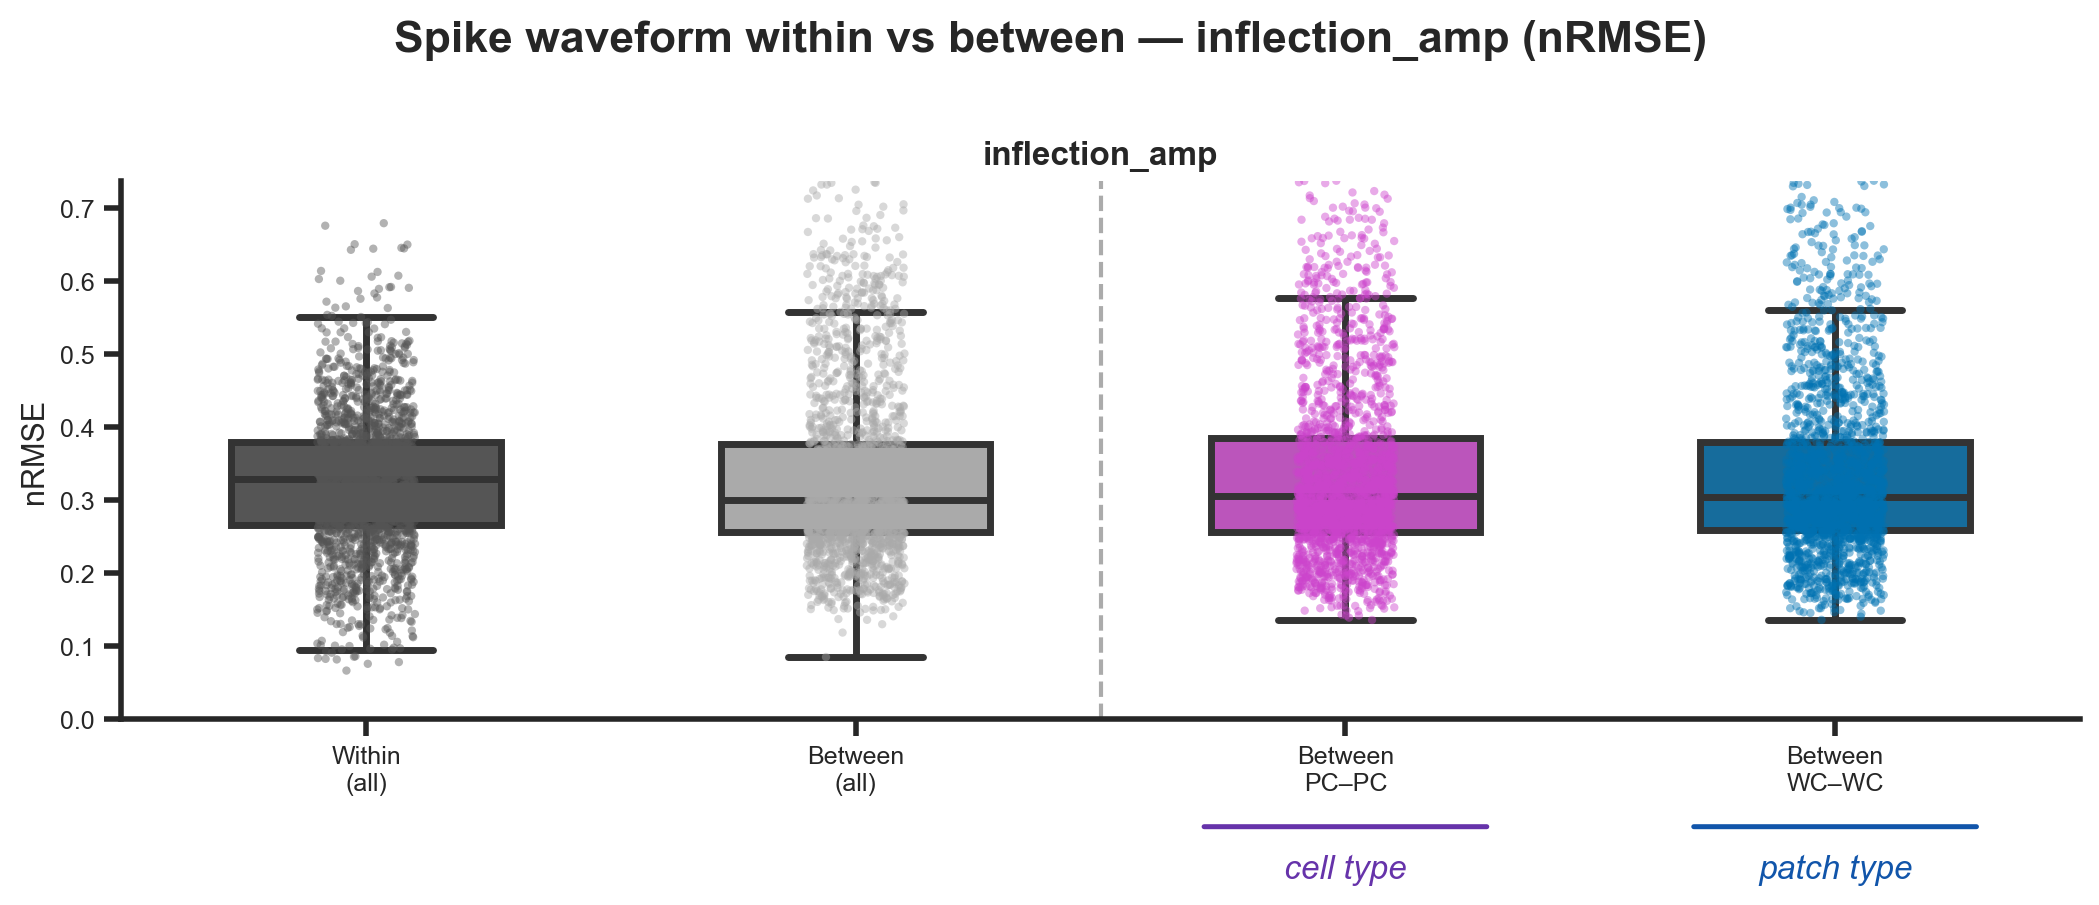

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


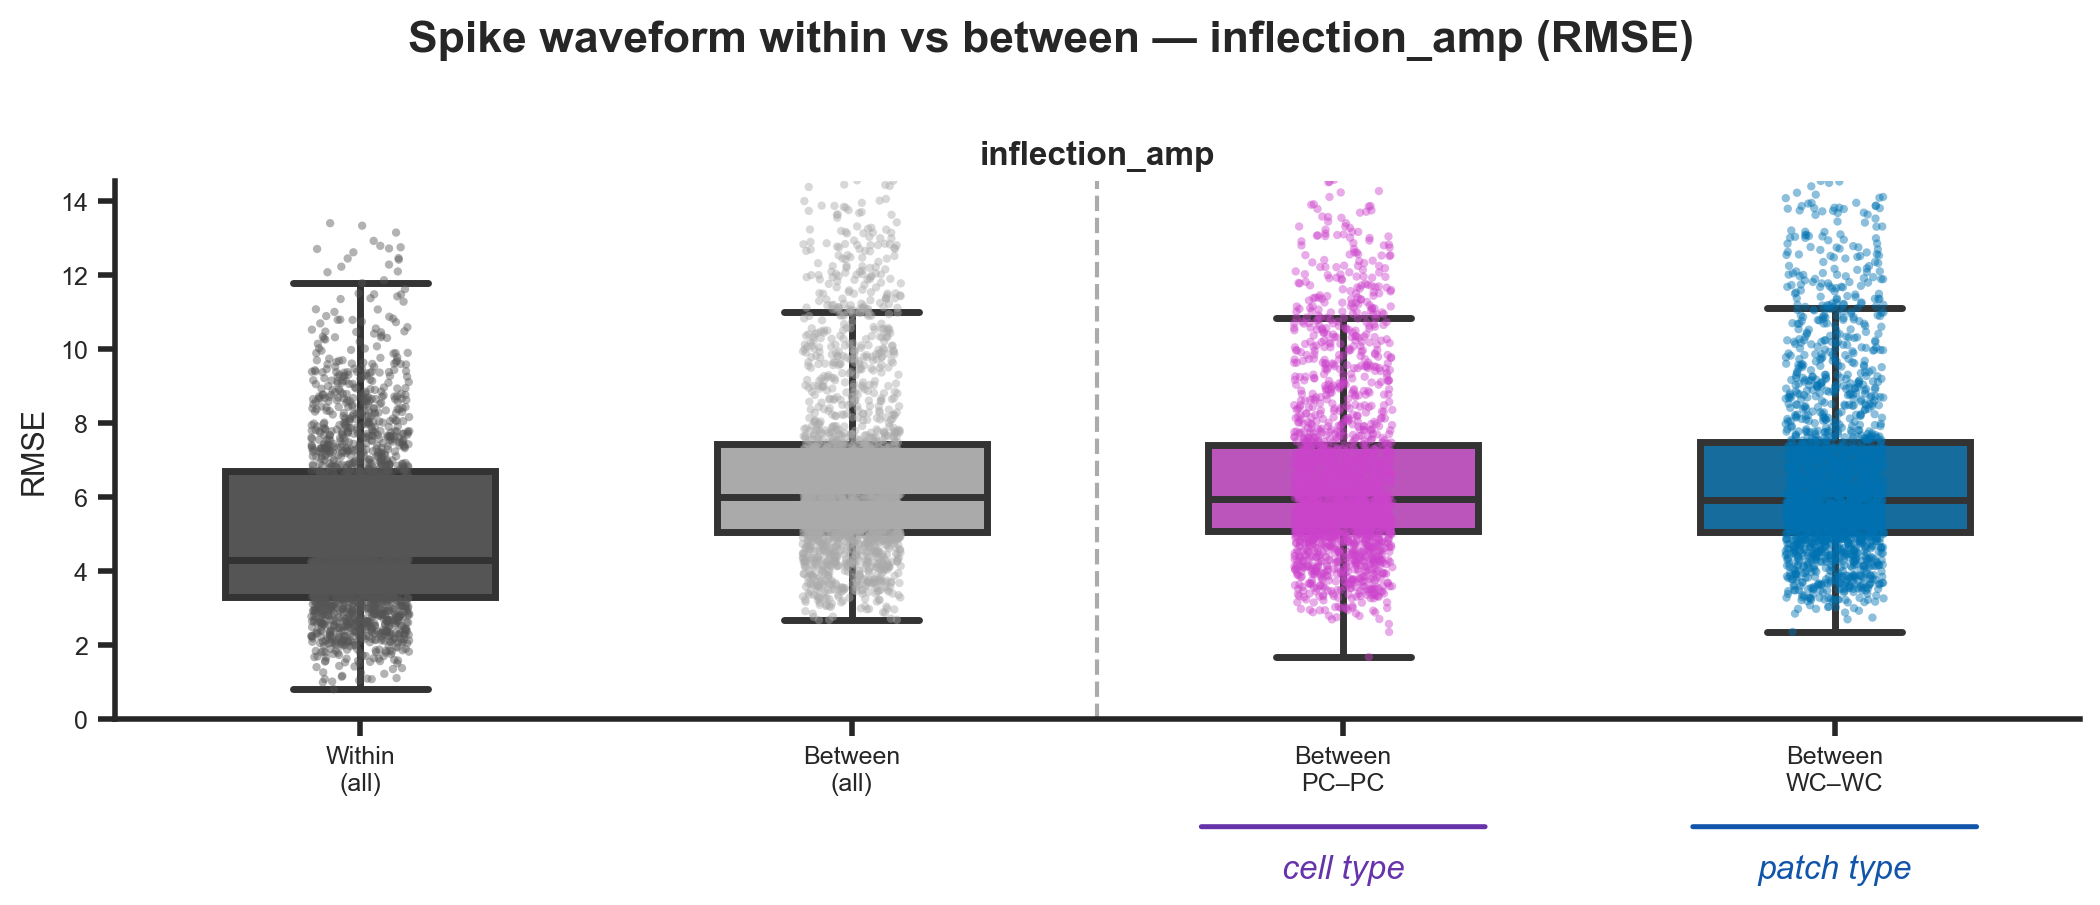

  inflection_time      Within (all)          : nRMSE median=0.06766  RMSE median=3.792  n=34,780
  inflection_time      Between (all)         : nRMSE median=0.3255  RMSE median=68.11  n=104,340
  inflection_time      Between PC–PC         : nRMSE median=0.3274  RMSE median=102.2  n=15,942
  inflection_time      Between IN–IN         : nRMSE median=0.2946  RMSE median=68.17  n=18,838
  inflection_time      Between Juxta–Juxta   : nRMSE median=0.2948  RMSE median=68.32  n=50,616
  inflection_time: cached → _feat_wbwf2_detailed_inflection_time.npz


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


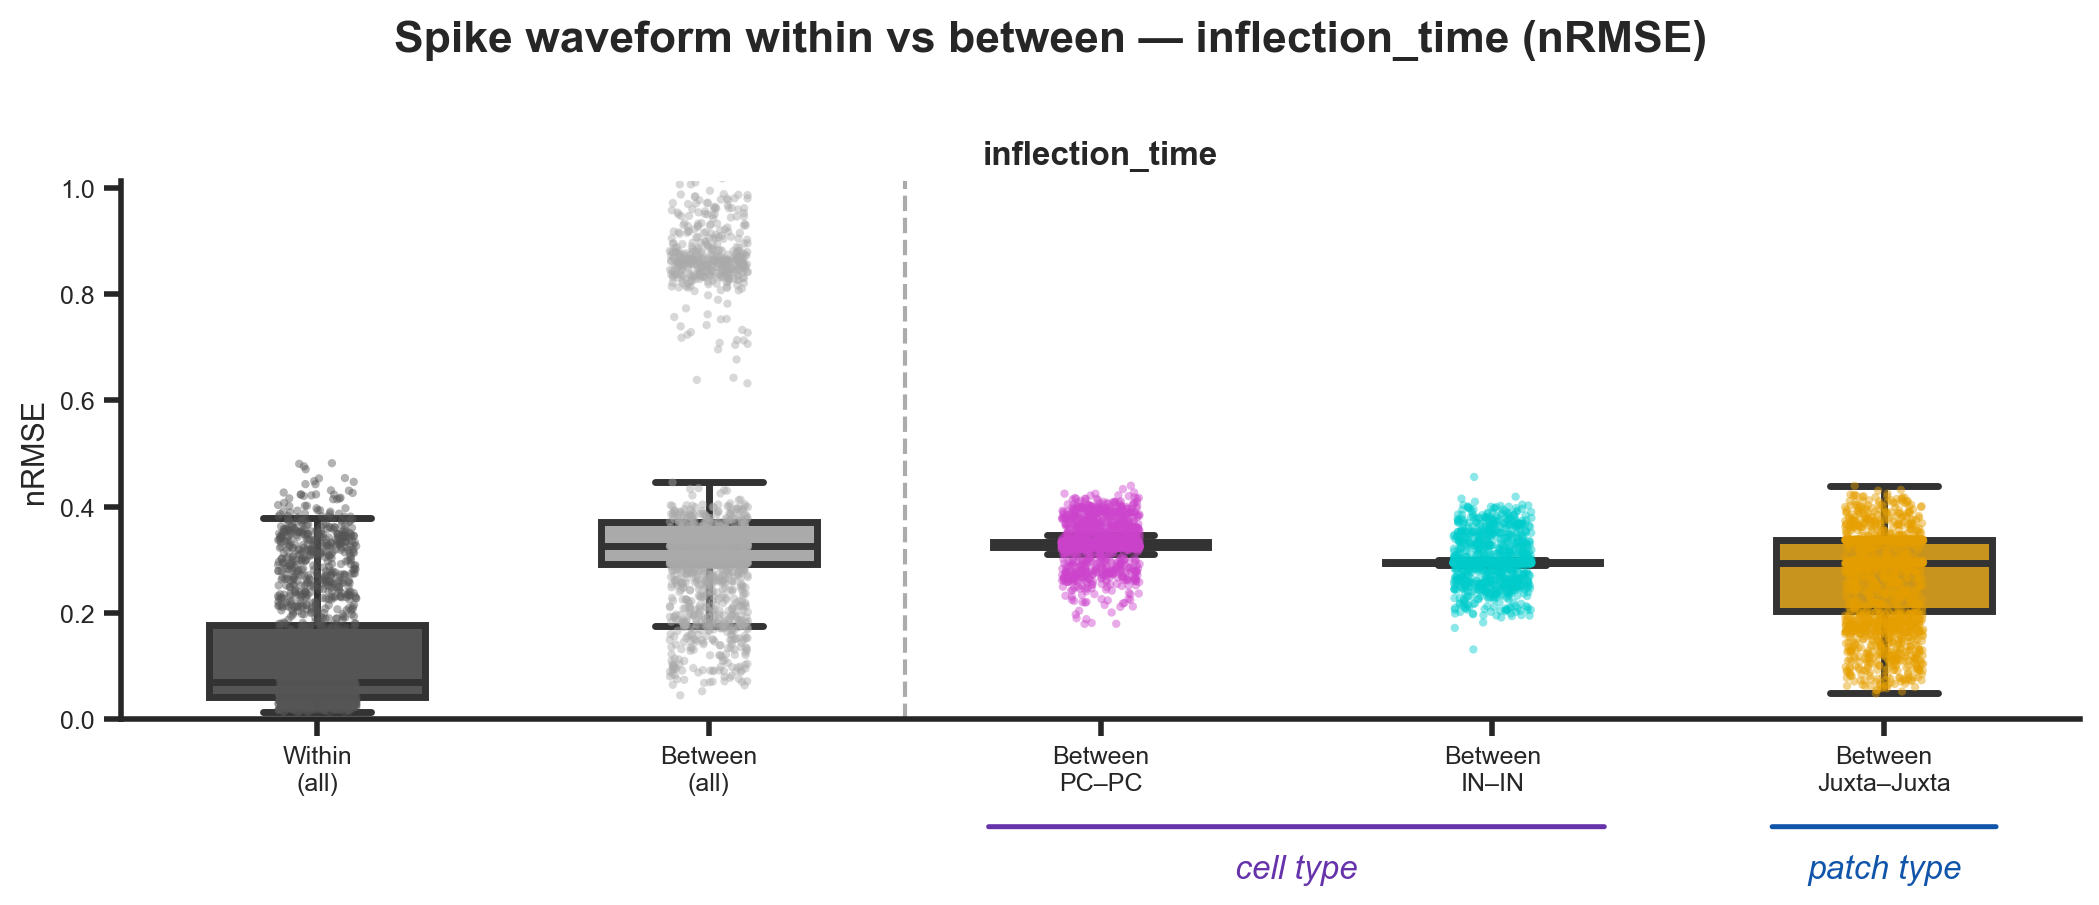

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2884: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="value", order=present,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2887: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="group", y="value", order=present,


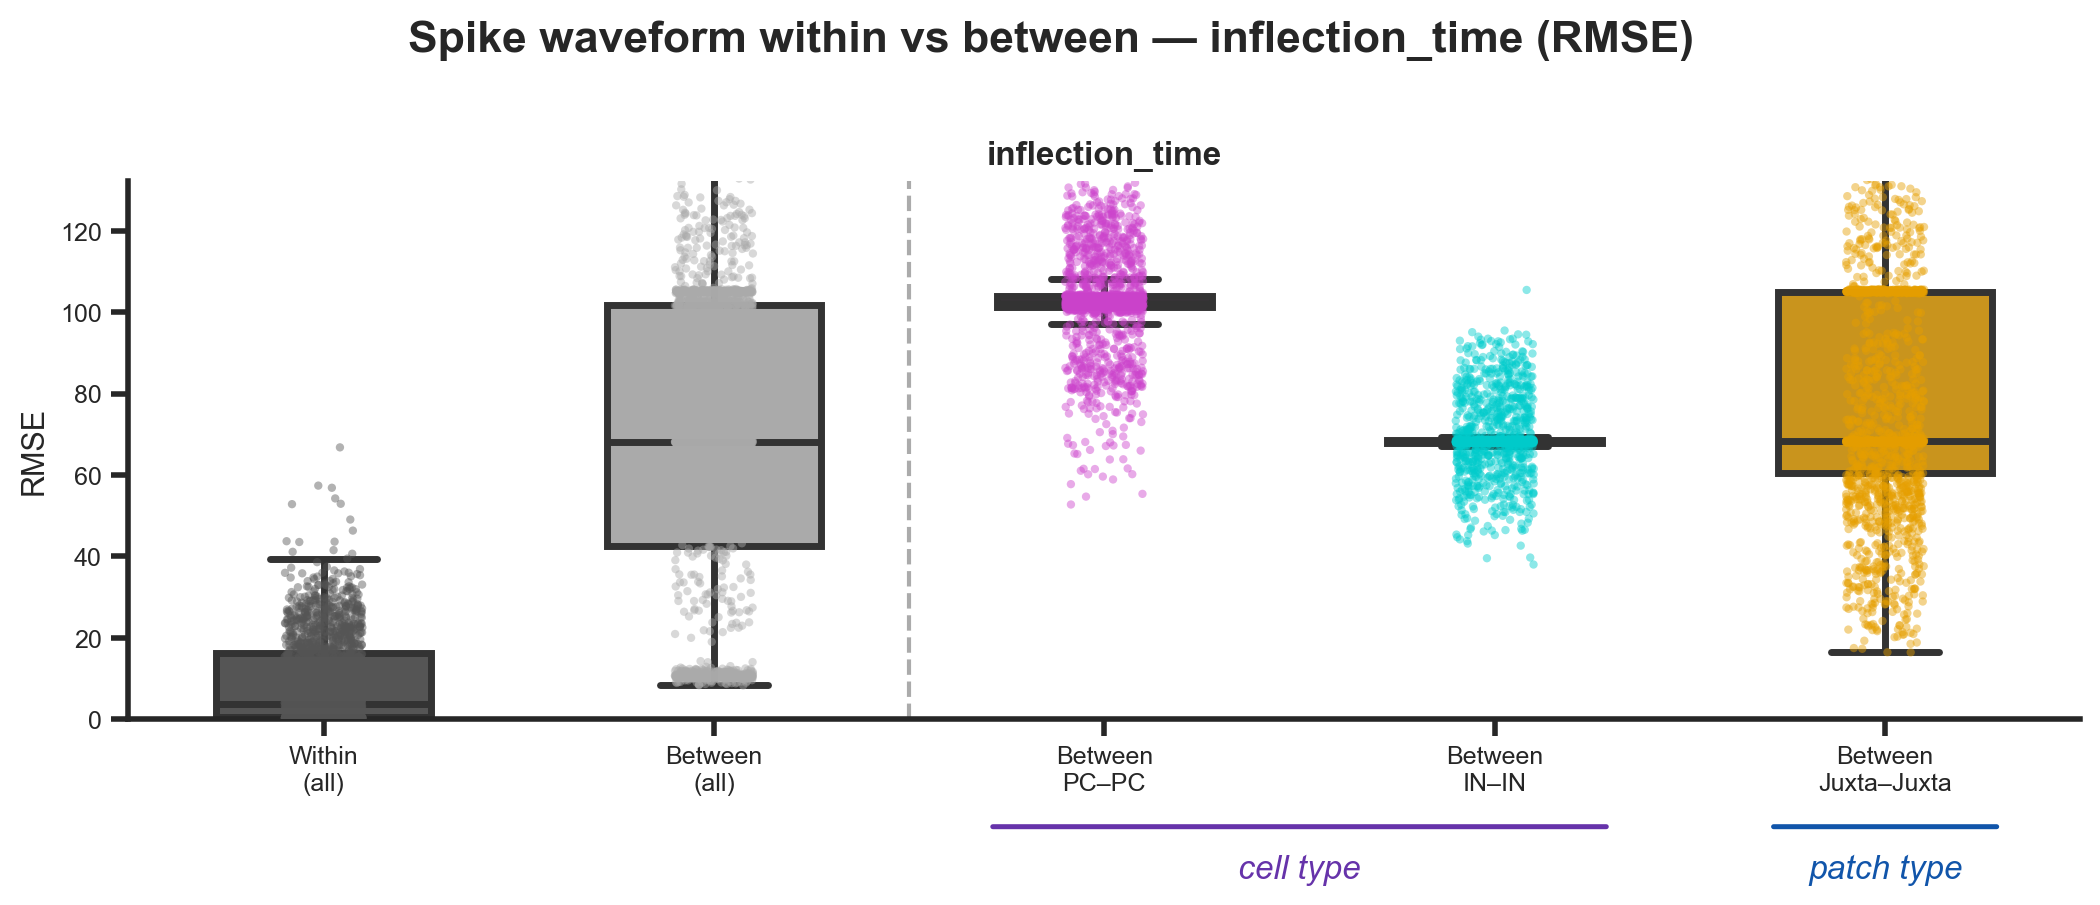

In [6]:
plot_spike_feature_within_vs_between(cluster_pickle_dir, spike_fit_dir, detailed=True, df_master=df_master)

Each spike is compared to the mean waveform of its own cell (within) and to the mean waveform of every other cell (between). Both distances are spike-to-average nRMSE/cos_sim, making the comparison scale-consistent. Within is ~167k spikes; between is ~7M comparisons across 38 cells.